In [1]:
import sys, os

# ml/ root → config.py yahan hai
ML_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
# ml/src/ → utils.py, dataset.py yahan hain
SRC_DIR = os.path.join(ML_ROOT, "src")

sys.path.insert(0, ML_ROOT)
sys.path.insert(0, SRC_DIR)

import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import config
from utils import get_label_map, set_seed

set_seed(config.SEED)
print(f"ML_ROOT : {ML_ROOT}")
print(f"SRC_DIR : {SRC_DIR}")
print("✅ Imports done")

ML_ROOT : d:\dermasense-web\ml
SRC_DIR : d:\dermasense-web\ml\src
✅ Imports done


In [2]:
train_df = pd.read_csv(config.TRAIN_CSV)
test_df  = pd.read_csv(config.TEST_CSV)

class_counts      = train_df[config.LABEL_COL].value_counts()
rare_classes      = class_counts[class_counts < 2].index.tolist()
train_df_filtered = train_df[~train_df[config.LABEL_COL].isin(rare_classes)].copy()

print(f"Train original : {len(train_df)}")
print(f"Rare classes   : {len(rare_classes)}")
print(f"Train filtered : {len(train_df_filtered)}")
print(f"Classes        : {train_df_filtered[config.LABEL_COL].nunique()}")

Train original : 4399
Rare classes   : 52
Train filtered : 4347
Classes        : 181


In [3]:
for df in [train_df_filtered, test_df]:
    if "Fitzpatrick" in df.columns:
        df["Fitzpatrick"] = (
            df["Fitzpatrick"]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(float)
        )
        df["Fitzpatrick"] = df["Fitzpatrick"].fillna(df["Fitzpatrick"].median())

print("✅ Fitzpatrick cleaned")
print(train_df_filtered["Fitzpatrick"].value_counts().sort_index())

✅ Fitzpatrick cleaned
Fitzpatrick
3.0    1122
4.0    2120
5.0     995
6.0     110
Name: count, dtype: int64


In [4]:
l2i, i2l = get_label_map(train_df_filtered[config.LABEL_COL])

train_part, val_part = train_test_split(
    train_df_filtered,
    test_size  = config.VAL_SPLIT,
    stratify   = train_df_filtered[config.LABEL_COL],
    random_state = config.SEED
)

print(f"Train : {len(train_part)} | Val : {len(val_part)} | Test : {len(test_df)}")
print(f"NUM_CLASSES : {len(l2i)}")

Train : 3694 | Val : 653 | Test : 1051
NUM_CLASSES : 181


In [5]:
os.makedirs(config.DATA_PROCESSED, exist_ok=True)

# Save splits
train_part.to_csv(os.path.join(config.DATA_PROCESSED, "train.csv"), index=False)
val_part.to_csv(os.path.join(config.DATA_PROCESSED, "val.csv"),   index=False)
test_df.to_csv(os.path.join(config.DATA_PROCESSED, "test.csv"),   index=False)

# Save label map
with open(os.path.join(config.DATA_PROCESSED, "label2idx.json"), "w") as f:
    json.dump(l2i, f, indent=2)

with open(os.path.join(config.DATA_PROCESSED, "idx2label.json"), "w") as f:
    json.dump({str(k): v for k, v in i2l.items()}, f, indent=2)

# Save rare classes list
with open(os.path.join(config.DATA_PROCESSED, "rare_classes.json"), "w") as f:
    json.dump(rare_classes, f, indent=2)

print("✅ Saved:")
for f in os.listdir(config.DATA_PROCESSED):
    print(f"   {f}")

✅ Saved:
   class_weights.npy
   idx2label.json
   label2idx.json
   rare_classes.json
   test.csv
   train.csv
   val.csv


In [6]:
# Reload and verify
t = pd.read_csv(os.path.join(config.DATA_PROCESSED, "train.csv"))
v = pd.read_csv(os.path.join(config.DATA_PROCESSED, "val.csv"))
e = pd.read_csv(os.path.join(config.DATA_PROCESSED, "test.csv"))

with open(os.path.join(config.DATA_PROCESSED, "label2idx.json")) as f:
    l2i_loaded = json.load(f)

print(f"train.csv  : {len(t)} rows")
print(f"val.csv    : {len(v)} rows")
print(f"test.csv   : {len(e)} rows")
print(f"label2idx  : {len(l2i_loaded)} classes")
print("\n✅ Preprocessing complete. Ready for training.")

train.csv  : 3694 rows
val.csv    : 653 rows
test.csv   : 1051 rows
label2idx  : 181 classes

✅ Preprocessing complete. Ready for training.


In [7]:
print("Quality distribution:")
print(train_part["Quality"].value_counts())
print("\nGradability distribution:")
print(train_part["Gradability"].value_counts())

# Sirf acceptable quality rakhenge
KEEP_QUALITY     = ["Good", "Acceptable", "Fair"]     # adjust after seeing output
KEEP_GRADABILITY = ["Gradable", "Partially Gradable"] # adjust after seeing output

# Check karo kitne remove honge
q_mask = train_part["Quality"].isin(KEEP_QUALITY) if "Quality" in train_part.columns else True
g_mask = train_part["Gradability"].isin(KEEP_GRADABILITY) if "Gradability" in train_part.columns else True

print(f"\nTrain before quality filter : {len(train_part)}")
print(f"Would remove               : {(~(q_mask & g_mask)).sum()} rows")

Quality distribution:
Quality
Yes, the quality is sufficient for me or another colleague to make a diagnosis.                      3680
The quality is sufficient, and NO DISCERNIBLE PATHOLOGY can be identified (image(s) look normal).      13
No, the quality is insufficient for me or another colleague to make a diagnosis                         1
Name: count, dtype: int64

Gradability distribution:
Gradability
Yes    3694
Name: count, dtype: int64

Train before quality filter : 3694
Would remove               : 3694 rows


Max samples in a class  : 416
Min samples in a class  : 2
Mean samples per class  : 20.4
Median samples per class: 7.0

Classes with < 5 samples : 71
Classes with < 10 samples: 112
Classes with > 50 samples: 15


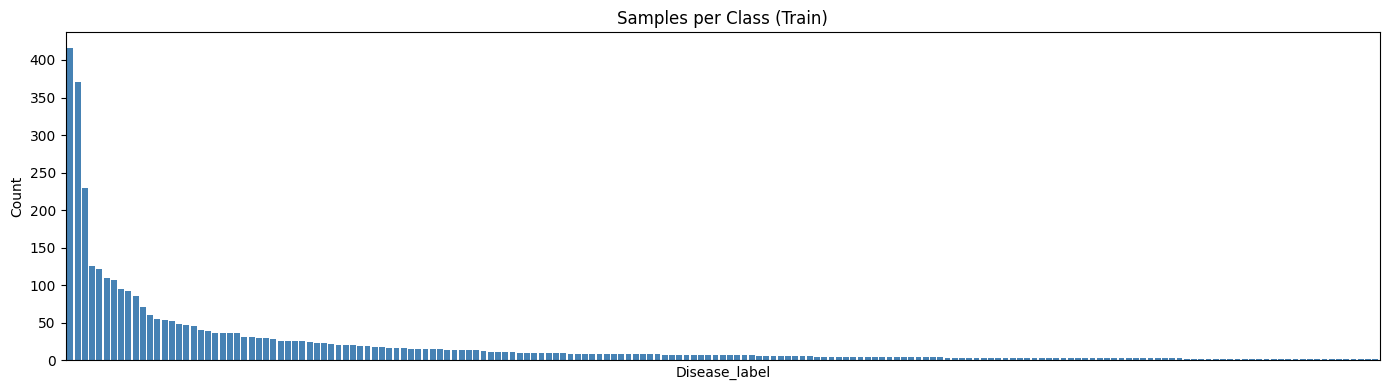

In [8]:
import matplotlib.pyplot as plt
import numpy as np

vc = train_part[config.LABEL_COL].value_counts()

print(f"Max samples in a class  : {vc.max()}")
print(f"Min samples in a class  : {vc.min()}")
print(f"Mean samples per class  : {vc.mean():.1f}")
print(f"Median samples per class: {vc.median():.1f}")
print(f"\nClasses with < 5 samples : {(vc < 5).sum()}")
print(f"Classes with < 10 samples: {(vc < 10).sum()}")
print(f"Classes with > 50 samples: {(vc > 50).sum()}")

# Distribution plot
plt.figure(figsize=(14, 4))
vc.plot(kind="bar", color="steelblue", width=0.8)
plt.title("Samples per Class (Train)")
plt.ylabel("Count")
plt.xticks([])
plt.tight_layout()
plt.savefig(f"{config.PLOTS_DIR}/class_imbalance.png", dpi=150)
plt.show()

In [9]:
import torch
import json

# Frequency-based class weights: rarer class → higher weight
class_counts_arr = np.array([vc.get(i2l[i], 1) for i in range(len(l2i))])
class_weights    = 1.0 / np.log1p(class_counts_arr)   # log smoothing
class_weights    = class_weights / class_weights.sum() * len(l2i)  # normalize
class_weights_t  = torch.tensor(class_weights, dtype=torch.float32)

print(f"Class weights — min: {class_weights.min():.4f} | max: {class_weights.max():.4f}")

# Save as numpy
np.save(os.path.join(config.DATA_PROCESSED, "class_weights.npy"), class_weights)
print("✅ class_weights.npy saved")

Class weights — min: 0.3097 | max: 1.7010
✅ class_weights.npy saved


In [11]:
from torch.utils.data import WeightedRandomSampler

# Per-sample weight = class weight of that sample's label
def make_sampler(df, l2i, class_weights_arr):
    sample_weights = np.array([
        class_weights_arr[l2i[label]]
        for label in df[config.LABEL_COL]
    ])
    sampler = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float32),
        num_samples = len(sample_weights),
        replacement = True
    )
    return sampler

sampler = make_sampler(train_part, l2i, class_weights)
print(f"✅ WeightedRandomSampler ready — {len(sampler)} samples")

# Save sampler config (weights only, sampler can't be pickled)
np.save(os.path.join(config.DATA_PROCESSED, "sample_weights.npy"), 
        np.array([class_weights[l2i[label]] for label in train_part[config.LABEL_COL]]))
print("✅ sample_weights.npy saved")

✅ WeightedRandomSampler ready — 3694 samples
✅ sample_weights.npy saved


In [12]:
print("="*55)
print("  PREPROCESSING COMPLETE — FINAL SUMMARY")
print("="*55)
print(f"  Train samples     : {len(train_part)}")
print(f"  Val   samples     : {len(val_part)}")
print(f"  Test  samples     : {len(test_df)}")
print(f"  Classes           : {len(l2i)}")
print(f"  Tabular features  : 96 (49 body + 47 descriptor)")
print(f"  Class weights     : min={class_weights.min():.3f} max={class_weights.max():.3f}")
print(f"  Sampler           : WeightedRandomSampler ✅")
print(f"  Augmentation      : Heavy (9 transforms) ✅")
print(f"  Image size        : {config.IMG_SIZE}x{config.IMG_SIZE}")
print("="*55)

# Verify all files present
files = os.listdir(config.DATA_PROCESSED)
print(f"\n  Saved files ({len(files)}):")
for f in sorted(files):
    size = os.path.getsize(os.path.join(config.DATA_PROCESSED, f))
    print(f"    {f:30s} {size/1024:.1f} KB")

  PREPROCESSING COMPLETE — FINAL SUMMARY
  Train samples     : 3694
  Val   samples     : 653
  Test  samples     : 1051
  Classes           : 181
  Tabular features  : 96 (49 body + 47 descriptor)
  Class weights     : min=0.310 max=1.701
  Sampler           : WeightedRandomSampler ✅
  Augmentation      : Heavy (9 transforms) ✅
  Image size        : 300x300

  Saved files (8):
    class_weights.npy              1.5 KB
    idx2label.json                 5.3 KB
    label2idx.json                 5.0 KB
    rare_classes.json              1.3 KB
    sample_weights.npy             29.0 KB
    test.csv                       418.3 KB
    train.csv                      1464.6 KB
    val.csv                        261.0 KB
